#Porównanie wartości NDVI dla różnych klas pokrycia terenu przy użyciu ANOVA i testów post-hoc
Projekt ma na celu sprawdzenie podobieństwa wartości NDVI pomiędzy różnymi klasami pokrycia terenu.

NDVI jest wskaźnikiem określającym kondycję roślinności. Stosuje się go do analizy danych teledetekcyjnych  z różnych źródeł.

$$NDVI = \frac{NIR - RED}{NIR + RED}$$


In [ ]:
import ee
import geemap
import numpy as np
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Obliczenie NDVI dla różnych klas terenu
W analizie wybrano 16 różnych obszarów z całej Polski.

Klasy pokrycia terenu dla których przeprowadzono analizę to:
* Lasy
* Łąki
* Pola uprawne
* Zabudowa
* Ziemia odkryta
* Woda


In [ ]:
# Authenticate Google Earth Engine
ee.Authenticate()
ee.Initialize(project="geemapanalysis")


In [ ]:
data_range = ["2021-05-01", "2021-07-30"] # Esa world cover rannge: 2021-01-01 - 2022-01-01

# Classes from ESA World Cover v200
cover_classes = {
  'Trees': 10,
  # 'Shrubland': 20,
  'Grassland': 30,
  'Cropland': 40,
  'Built-up': 50,##
  'Bare / sparse vegetation': 60,
  # 'Snow and ice': 70,
  'Permanent water bodies': 80,
  # 'Herbaceous wetland': 90,
  # 'Mangroves': 95,
  # 'Moss and lichen': 100
}

# Analysed locations from Poland
locations = {
  'roznow' : [49.74, 20.72],
  'dabrowa gornicza' : [50.345, 19.213],
  'zator' : [50, 19.44],
  'lublin' : [51.217, 22.56],
  'gizycko': [54.03, 21.73],
  'gdansk': [54.35, 18.64],
  'warszawa': [52.2297, 21.0122],
  'bydgoszcz': [53.1266, 18.0005],
  'poznan': [52.4064, 16.9252],
  'wroclaw': [51.1079, 17.0385],
  'krakow': [50.0614, 19.9375],
  'koszalin': [54.206, 16.173],
  'szczecin': [53.4237, 14.6246],
  'bialystok': [52.2297, 21.0122],
  'lodz': [51.752, 19.454],
  'olsztyn': [53.7559, 20.4849]
}

radius = 15000


###  Utworzenie bounding boxów


In [ ]:
def create_square_buffer(lat, lon, radius_m):
  """
  Create a square buffer around a point
  """

  point = ee.Geometry.Point([lon, lat])

  return point.buffer(radius_m).bounds()


Utworzenie bounding boxów dla lokacji wybranych w analizie. Lokacje zostały wybrane tak, żeby zawierały wszystkie klasy terenu, były rozłożone na terenie całej Polski oraz żeby ilość pikseli w każdej z klas nie była zbyt mała.

Wokół każdej z lokalizacji został utworzony prostokątny obszar o wymiarze 15 x 15 km, co daje 225 km^2. Do analizy posłużono się 16 obszarami, co przekłada się na łączną powierzchnię wynoszącą 3600 km^2.

In [ ]:
rois = []

for place, coord in locations.items():
  roi = create_square_buffer(coord[0], coord[1], 15000)
  rois.append(roi)


### Wizualizacja bounding boxów obszarów
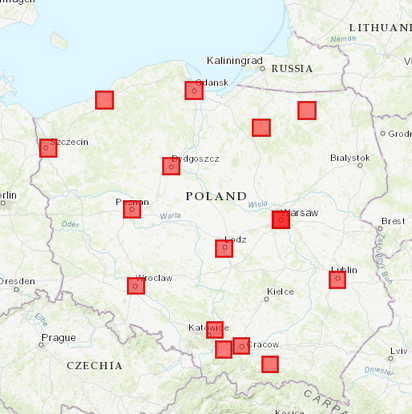

In [ ]:
Map = geemap.Map(center=(49.74, 20.72), basemap="Esri.WorldTopoMap", zoom=8)

for i, roi in enumerate(rois):
  Map.addLayer(roi, {'color': 'red'}, f"ROI {i+1}")

Map


### Obliczenie NDVI w obszarach

In [ ]:
def get_sentinel2_image(data_range, roi):
  '''
  Get Sentinel-2 image for given date range and roi
  '''

  s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi)
    .filterDate(data_range[0], data_range[1])
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
  )

  image = s2.median().clip(roi)

  return image


def get_ndvi(image):
  '''
  Calculate NDVI for given image
  '''

  ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

  return ndvi


def add_ndvi_to_map(ndvi, roi, Map, name_ndvi="NDVI", name_roi="ROI"):
  '''
  Add NDVI to map
  '''

  Map.addLayer(
    ndvi,
    {
      'min': -1,
      'max': 1,
      'palette': ['blue', 'white', 'green']
    },
    name_ndvi
  )

  # Change geometry to feature collection fo visualization
  roi = ee.FeatureCollection([
    ee.Feature(roi)
])

  roi_style = roi.style(
    color='red',
    fillColor='00000000',
    width=2
  )

  Map.addLayer(roi_style, {}, name_roi)


In [ ]:
# Get Sentinel-2 images
images = []
ndvi_images = []

for roi in rois:
  image = get_sentinel2_image(data_range, roi)
  images.append(image)

for image in images:
  ndvi = get_ndvi(image)
  ndvi_images.append(ndvi)


### Wizualizacja NDVI w obszarach
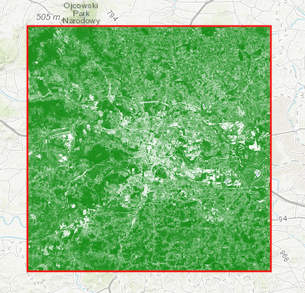

In [ ]:
# Incialize map instance
Map = geemap.Map(center=(49.74, 20.72), basemap="Esri.WorldTopoMap", zoom=8)

for i, ndvi in enumerate(ndvi_images):
  add_ndvi_to_map(ndvi, rois[i], Map, f"NDVI {i+1}", f"ROI {i+1}")

Map


### Obliczenie NDVI wewnątrz klas
Użyta warstwa klas pokrycia terenu pochodzi z kolekcji zdjęć ESA World Cover v200. Zostały one opracowane na podstawie zdjęć z Sentinel-1 i Sentinel-2, zostały one opracowane dla 2021 roku i cechują globalnym pokryciem planety z 10m rozdzielczością przestrzenną.

In [ ]:
def get_world_cover(roi):
  '''
  Get world cover for given roi
  '''

  world_cover = (
      ee.ImageCollection("ESA/WorldCover/v200")
      .first()
      .clip(roi)
  )

  return world_cover

def get_ndvi_means(cover_classes, ndvi, roi, results):
  '''
  Get ndvi means for given cover classes
  '''

  world_cover = get_world_cover(roi)

  for class_name, class_value in cover_classes.items():
    mask = world_cover.eq(class_value).focal_min(1) # Erode mask


    ndvi_in_class = ndvi.updateMask(mask)

    mean_ndvi_in_class = ndvi_in_class.reduceRegion(
      reducer=ee.Reducer.mean(),
      geometry=roi,
      scale=10,
      maxPixels=1e13
    )

    value = mean_ndvi_in_class.getInfo()['NDVI']

    # Create list if not exist
    if class_name not in results:
      results[class_name] = []

    # Add to list
    results[class_name].append(value)


In [ ]:
results = {}

# Calculate mean NDVI for each ROI and store it in results
for ndvi, roi in zip(ndvi_images, rois):
  get_ndvi_means(cover_classes, ndvi, roi, results)



In [ ]:
results_df = pd.DataFrame(results)

results_df

,Trees,Grassland,Cropland,Built-up,Bare / sparse vegetation,Permanent water bodies
0,0.855458,0.721652,0.647585,0.262859,0.053098,-0.256159
1,0.766478,0.685043,0.586616,0.237768,0.089067,-0.060986
2,0.816623,0.723312,0.618656,0.281408,0.076070,0.084436
3,0.760370,0.671917,0.639624,0.263174,0.105324,-0.038650
4,0.843533,0.739494,0.691510,0.292299,0.087710,-0.084517
5,0.823309,0.687551,0.736880,0.235489,0.076043,-0.173261
6,0.758261,0.695808,0.480848,0.244762,0.090479,-0.034241
7,0.769163,0.666083,0.615725,0.258536,0.112360,-0.015450
8,0.776621,0.627549,0.604373,0.237152,0.082915,0.109020
9,0.816504,0.702538,0.589706,0.239851,0.093570,0.057710


In [ ]:
results_df_melted = results_df.melt(
    var_name='Class',
    value_name='NDVI'
)

results_df_melted

,Class,NDVI
0,Trees,0.855458
1,Trees,0.766478
2,Trees,0.816623
3,Trees,0.760370
4,Trees,0.843533
...,...,...
91,Permanent water bodies,-0.158826
92,Permanent water bodies,-0.052584
93,Permanent water bodies,-0.034241
94,Permanent water bodies,0.144300


Na wykresie box-plot można zauważyć duże różnice w wartościach NDVI. Klasy lasów, łąk i pól uprawnych mają wysokie średnie wartości wskaźnika, podczas gdy zabudowa, ziemia i woda niskie.

Średnia wartość dla zabudowy wynosi 0.3 co wskazuje, że na tych terenach można zaobserwować jakąś roślinność.

Ziemia odkryta ma najmniejszą rozpiętość wartości, klasa ta ma najmniejsze wewnętrzne różnice.

Najbardziej zróżnicowana jest klasa wody, spowodowane może to być przez występowanie zarówno małych jak i dużych zbiorników. Na małych zbiornikach pikseli brzegowych, na których występuje roślinność wodna jest stosunkowo dużo. Na dużych obszarach wodnych przybrzeżna roślinność ma mniejszy wpływ na wartość wskaźnika NDVI, więc jest co za tym idzie mniejszy.

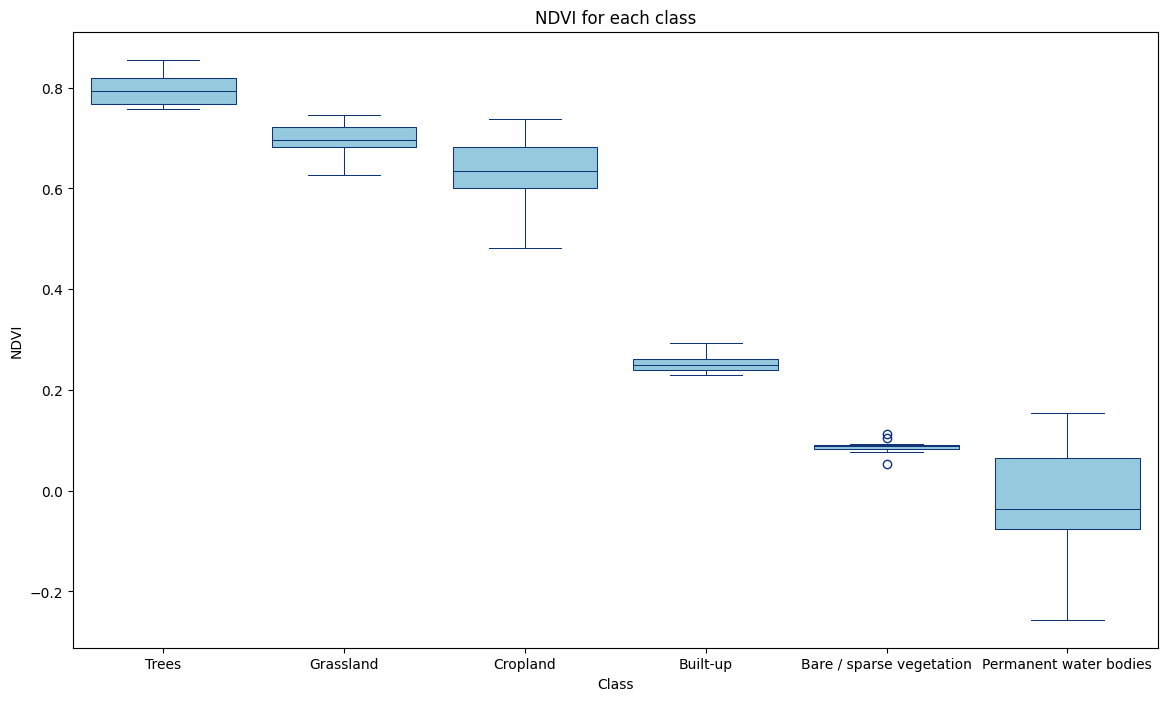

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.boxplot(data=results_df, ax=ax, color="skyblue", linecolor="#137", linewidth=.75)

ax.set_title("NDVI for each class")
ax.set_xlabel("Class")
ax.set_ylabel("NDVI")

plt.show()

Na wykresie przedstawiającym rozkład wartości NDVI zauważyć można, że klasy gleb i zabudowy mają wąskie rozkłady, są najmniej rozrzucone wokół swoich średnich. Woda i pola uprawne mają bardziej spłaszczone rozkłady, co za ty idzie są najbardziej wewnętrznie zróżnicowane.

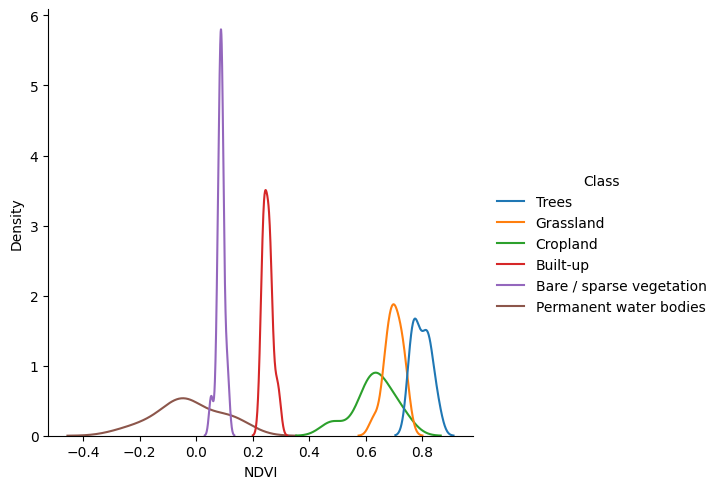

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(results_df_melted, x="NDVI", hue="Class", kind="kde")

## ANOVA
h0: średnie NDVI w grupach jest takie same

h1: średnia wartość NDVI pomiędzy grupami jest różna

In [ ]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats
from scipy.stats import f_oneway

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# model ANOVA
model = ols('NDVI ~ C(Class)', data=results_df_melted).fit()

# tabela ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)


            sum_sq    df           F        PR(>F)
C(Class)  9.612056   5.0  545.308334  1.140280e-65
Residual  0.317283  90.0         NaN           NaN


Wyniki testu ANOVA wskazują, że powinno się odrzucić hipotezę H0 i przyjąć H1 mówiącą, że conajmniej w jednej z grup pokrycia terenu średnia wartość NDVI się różni od innych.

By sprawdzić czy wynik ANOVY jest poprawny należy również sprawdzić czy spełnione są następujące założenia:
* Niezależność obserwacji względem siebie
* Próbki powinny być wybrane losowo
* Dane w każdej z grup powinny mieć rozkład normalny
* Wariancja w grupach powinna być taka sama


Dwa pierwsze założenia są już spełnione. Obserwacje są niezależne między sobą, wszystkie obserwacje pochodzą z innych obszarów. Próbki zostały wybrane w sposób poł-losowy tj. kierowano się wyborem miejsc, gdzie dostępne są wszystkie analizowane klasy terenu i ich powierzchnia jest znacząca.

Dwa ostanie założenia należy sprawdzić odpowiednimi testami tj. testem Levene'a (sprawdzenie wariancji) i testem Shapiro-Wilk (sprawdzenie normalności rozkładów).


### Test Shapiro-Wilka
H0: populacja jest dana rozkładem normalnym

H1: populacja pochodzi z innego rozkładu niż normalny

Konieczne założenia zostały spełnione:
* Wartości ciągłe
* Niezależność obserwacji
* Silny dla liczby obserwacji: 3 < N < 50

Z testu wynika, że dane pochodzą z rozkładu normalnego.

In [ ]:
from scipy.stats import shapiro

shapiro_wilk = pd.DataFrame(columns = ["class", "w_stat", "p_value", "reject"])

for column in results_df.columns:
  w_stats, p_value = shapiro(results_df[column])
  alpha = 0.05
  reject = True

  if p_value > alpha:
    reject = False

  shapiro_wilk.loc[len(shapiro_wilk.index)] = [column, w_stats, p_value, reject]

shapiro_wilk



,class,w_stat,p_value,reject
0,Trees,0.926601,0.215250,False
1,Grassland,0.968575,0.815027,False
2,Cropland,0.922178,0.182850,False
3,Built-up,0.922979,0.188348,False
4,Bare / sparse vegetation,0.909942,0.116120,False
5,Permanent water bodies,0.958573,0.635987,False


### Test Levene'a
* h0: wariancja we wszystkich grupach jest taka sama
* h1: wariancja różni się między grupami

Z testu Levene'a otrzymano, że należy odrzucić hipotezę H0 na rzecz alternatywnej, mówiącej o braku jednakowości wariancji między grupami. P-value jest wyraźnie mniejsze od 0,05.

In [ ]:
from scipy.stats import levene

alpha = 0.05

w_stats, p_value = levene(results_df["Trees"], + results_df["Grassland"],
                            + results_df["Cropland"], + results_df["Built-up"],
                            + results_df["Bare / sparse vegetation"], + results_df["Permanent water bodies"],
                            center='mean'
                          )

if p_value > alpha:
    print(f"We do not reject the null hypothesis, p-value: {p_value}")
else:
    print(f"Reject the Null Hypothesis, p-value: {p_value}")

Reject the Null Hypothesis, p-value: 1.0531318403278117e-07


## ANOVA dla danych po transformacji

### Transformacja Box-Cox
By spełnić wymagania testu ANOVA, o jednorodności wariancji w pomiędzy grupami, postanowiono dokonać transformacji danych  za pomocą przekształcenia box-cox.

In [ ]:
from scipy.stats import boxcox

transformed_df = pd.DataFrame()

for column in results_df.columns:
  transformed_data, lambda_opt = boxcox(results_df[column] + 1.01)
  transformed_df[column] = transformed_data

transformed_df

,Trees,Grassland,Cropland,Built-up,Bare / sparse vegetation,Permanent water bodies
0,0.096220,40.514846,3.684737,0.036839,0.093069,-0.236602
1,0.096121,31.917143,2.875512,0.036801,0.184349,-0.050597
2,0.096183,40.950269,3.280692,0.036857,0.147151,0.095729
3,0.096112,29.262986,3.569762,0.036840,0.238853,-0.028527
4,0.096209,45.424243,4.374222,0.036864,0.180214,-0.073680
5,0.096190,32.448417,5.192811,0.036797,0.147078,-0.159150
6,0.096109,34.254812,1.810384,0.036814,0.188713,-0.024153
7,0.096125,28.148917,3.241837,0.036834,0.265538,-0.005446
8,0.096135,21.705769,3.094787,0.036800,0.166086,0.121063
9,0.096183,35.794041,2.912749,0.036805,0.198505,0.068379


In [ ]:
transformed_df_melted = pd.melt(
    transformed_df,
    var_name='Class',
    value_name='NDVI'
)

In [ ]:
# model ANOVA
model = ols('NDVI ~ C(Class)', data=transformed_df_melted).fit()

# tabela ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                sum_sq    df          F        PR(>F)
C(Class)  16144.345612   5.0  398.81971  8.619632e-60
Residual    728.645585  90.0        NaN           NaN


### Test Levenea i Shapiro-Wilk

In [ ]:
# Levene test for the same variance
alpha = 0.05

w_stats, p_value = levene(results_df["Trees"], + results_df["Grassland"],
                            + results_df["Cropland"], + results_df["Built-up"],
                            + results_df["Bare / sparse vegetation"], + results_df["Permanent water bodies"],
                            center='mean'
                          )
print("Shapiro-Wilk Test: ")
if p_value > alpha:
    print(f"We do not reject the null hypothesis, p-value: {p_value}")
else:
    print(f"Reject the Null Hypothesis, p-value: {p_value}")

print()

# Shapiro-wilk for normal  distribution test
shapiro_wilk = pd.DataFrame(columns = ["class", "w_stat", "p_value", "reject"])

for column in results_df.columns:
  w_stats, p_value = shapiro(results_df[column])
  alpha = 0.05
  reject = True

  if p_value > alpha:
    reject = False

  shapiro_wilk.loc[len(shapiro_wilk.index)] = [column, w_stats, p_value, reject]

print("Shapiro-Wilk Test: ")
shapiro_wilk



Shapiro-Wilk Test: 
Reject the Null Hypothesis, p-value: 1.0531318403278117e-07

Shapiro-Wilk Test: 


,class,w_stat,p_value,reject
0,Trees,0.926601,0.215250,False
1,Grassland,0.968575,0.815027,False
2,Cropland,0.922178,0.182850,False
3,Built-up,0.922979,0.188348,False
4,Bare / sparse vegetation,0.909942,0.116120,False
5,Permanent water bodies,0.958573,0.635987,False


Wynik testu ANOVA wskazuje, że grupy w postaci klas pokrycia terenu różnią się wartością NDVI. Test shapiro-wilka wskazuje, że dane mają rozkład normalny. Z testu Levene'a wynika, że wariancja nie jest jednorodna pomiędzy grupami. Z tego powodu test ANOVA należy odrzucić, ponieważ niespełnienia kryteriów o jednorodności wariancji.

## Anova Welch'a
Zarówno dane przed transformacją box-cox jak i przed nie posiadają jednorodnej wariancji między grupami. Z tego powodu nie można zastosować na nich klasycznej analizy ANOVA. Dlatego do analizy podobieństwa średnich wartości NDVI w grupach wykorzystany zostanie test ANOVA Welch'a.

H0: Średnie NDVI są takie same we wszystkich klasach terenu

H1: średnie NDVI są różne

In [ ]:
!pip install pingouin > /dev/null

In [ ]:
import pingouin as pg

pg.welch_anova(dv='NDVI', between='Class', data=results_df_melted)

,Source,ddof1,ddof2,F,p_unc,np2
0,Class,5,40.14103,2103.291344,1.985050e-47,0.968046


Po przeprowadzeniu testu ANOVA Welch'a odrzucono hipotezę H0, p-value jest znacząco mniejsze od 0.05. F-value równe 2100 wskazuje na ogromne różnice pomiędzy grupami. Wynika z tego, że klasy różnią się średnią wartością NDVI.

### Games Howell post-hoc test

Z uwagi na brak jednorodności wariancji posłużono się testem Games Howell do analizy wszystkich klas między sobą.

Najbardziej zbliżona jest do siebie klasa wody oraz gleby odkrytej, jak również klasa łąk i pól uprawnych. Wartość efektu jest dla nich najniższa i wynosi mniej niż 1,4. Obliczone p-value dla nich jest mniejsze niż 0,05.

Dla wszystkich połączeń wartość p-value < 0,05 a otrzymane wartości efektu są wysokie. Wskazuje to, że wszystkie klasy są od siebie różne.

In [ ]:
import pingouin as pg
df = pg.read_dataset("penguins")
pg.pairwise_gameshowell(data=results_df_melted, dv="NDVI", between="Class").round(3)


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Bare / sparse vegetation,Built-up,0.087,0.253,-0.166,0.005,-30.901,28.017,0.000,-10.650
1,Bare / sparse vegetation,Cropland,0.087,0.629,-0.542,0.019,-28.914,15.929,0.000,-9.965
2,Bare / sparse vegetation,Grassland,0.087,0.698,-0.611,0.008,-72.738,20.126,0.000,-25.068
3,Bare / sparse vegetation,Permanent water bodies,0.087,-0.027,0.114,0.029,3.932,15.382,0.013,1.355
4,Bare / sparse vegetation,Trees,0.087,0.797,-0.710,0.008,-83.600,20.007,0.000,-28.812
5,Built-up,Cropland,0.253,0.629,-0.376,0.019,-19.853,16.600,0.000,-6.842
6,Built-up,Grassland,0.253,0.698,-0.445,0.009,-50.333,23.346,0.000,-17.347
7,Built-up,Permanent water bodies,0.253,-0.027,0.280,0.029,9.608,15.658,0.000,3.311
8,Built-up,Trees,0.253,0.797,-0.544,0.009,-60.912,23.173,0.000,-20.993
9,Cropland,Grassland,0.629,0.698,-0.069,0.020,-3.443,20.121,0.027,-1.187


### Tamhene T2 post-hoc test
Do potwierdzenia wyników przeprowadzono jeszcze test Tamhene'a T2. Test ten potwierdza wcześniejsze wyniki analizy, wartości NDVI w klasach są znacząco różne.

In [ ]:
!pip install scikit_posthocs > /dev/null

In [ ]:
import scikit_posthocs as sp

sp.posthoc_tamhane(results_df_melted, val_col='NDVI', group_col='Class', welch=True).round(3)

,Trees,Grassland,Cropland,Built-up,Bare / sparse vegetation,Permanent water bodies
Trees,1.0,0.000,0.000,0.0,0.000,0.000
Grassland,0.0,1.000,0.015,0.0,0.000,0.000
Cropland,0.0,0.015,1.000,0.0,0.000,0.000
Built-up,0.0,0.000,0.000,1.0,0.000,0.000
Bare / sparse vegetation,0.0,0.000,0.000,0.0,1.000,0.008
Permanent water bodies,0.0,0.000,0.000,0.0,0.008,1.000


## Wnioski
Przeprowadzona analiza wykazała istotne różnice w wartościach NDVI pomiędzy analizowanymi klasami pokrycia terenu: lasami, łąkami, polami uprawnymi, zabudową, glebą oraz wodą.

Wyniki testu Games–Howell wskazują, że wszystkie klasy różnią się między sobą w sposób statystycznie istotny.

Najmniejsze różnice zaobserwowano pomiędzy łąkami a polami uprawnymi oraz pomiędzy wodą a glebą, co jest zgodne z ich podobnym charakterem spektralnym.
Największe różnice występują pomiędzy klasą drzew a klasami o niskiej wartości NDVI, takimi jak woda i tereny zabudowane.